In [1]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import time
import seaborn as sns

import pymeasure.instruments.srs as srs

reload(srs)
# lockin = srs.SR830('GPIB2::9::INSTR')

lockin_gen = srs.SR830('GPIB0::11::INSTR')
print(lockin_gen.id)

lockin_gen.time_constant = 0.1
lockin_gen.filter_slope = 24
print(f'time constant is {lockin_gen.time_constant}')
print(f'filter rolloff slope is {lockin_gen.filter_slope}')

# set the sample frequency to be 10 time constants (or roughly that, if you use filter slope of 24db/oct)
samp_freq = 1
buffer_size = 5

lockin_gen.sample_frequency = samp_freq

print(f'lockin buffer sampling frequency is {lockin_gen.sample_frequency}')
print(f'The number of samples to be collected is {buffer_size}')

Stanford_Research_Systems,SR830,s/n53725,ver1.07
time constant is 0.1
filter rolloff slope is 24
lockin buffer sampling frequency is 1
The number of samples to be collected is 5


Tune the scalings and collect a sample of data

In [2]:
for ch in ['X', 'Y']:
    lockin_gen.set_scaling(ch, 0, expand = 1)
    print('The scaling is turned of ', lockin_gen.get_scaling(ch))

print('Lockin xy is ', 1e3*np.array(lockin_gen.xy))

def zero_and_expand(instr:srs.SR830, ch, expansion = 100):
    instr.auto_offset(channel = ch)
    instr.set_scaling(ch, expand = expansion)

for ch in ['X', 'Y']:
    zero_and_expand(lockin_gen, ch)
    print('The new scaling is ', lockin_gen.get_scaling(ch))

time.sleep(2)
print(lockin_gen.lia_status)

x_response, y_response = lockin_gen.buffer_measure_fast(buffer_size)

# x_vals = lockin_gen.output_conversion('X')(x_response)
# y_vals = lockin_gen.output_conversion('Y')(y_response)

print('X is ', 1e3*(x_response))
print('Y is', 1e3*( y_response))

The scaling is turned of  (0.0, 1)
The scaling is turned of  (0.0, 1)
Lockin xy is  [505.375 505.375]
The new scaling is  (50.54, 100)
The new scaling is  (50.54, 100)
0
X is  [505.40566667 505.404      505.42233333 505.39966667 505.41133333]
Y is [505.421      505.42733333 505.40666667 505.427      505.41633333]


Process bytes to floats

Adjusting the readout for scaling

In [3]:
x_precision = np.abs(np.min(np.diff(x_response)))
y_precision = np.abs(np.min(np.diff(y_response)))

print(f'typical precision at a sensitivity of {lockin_gen.sensitivity*1e3}mV is  {1e3*20/(3*10**4)}uV')
print(f'precision in the measruement of the X channel is {x_precision*1e6}uV')
print(f'precision in the measurement of the Y channel is {y_precision*1e6}uV')

typical precision at a sensitivity of 1000.0mV is  0.6666666666666666uV
precision in the measruement of the X channel is 22.666666666726343uV
precision in the measurement of the Y channel is 20.66666666666883uV


Text(0, 0.5, '$Y$ (mV)')

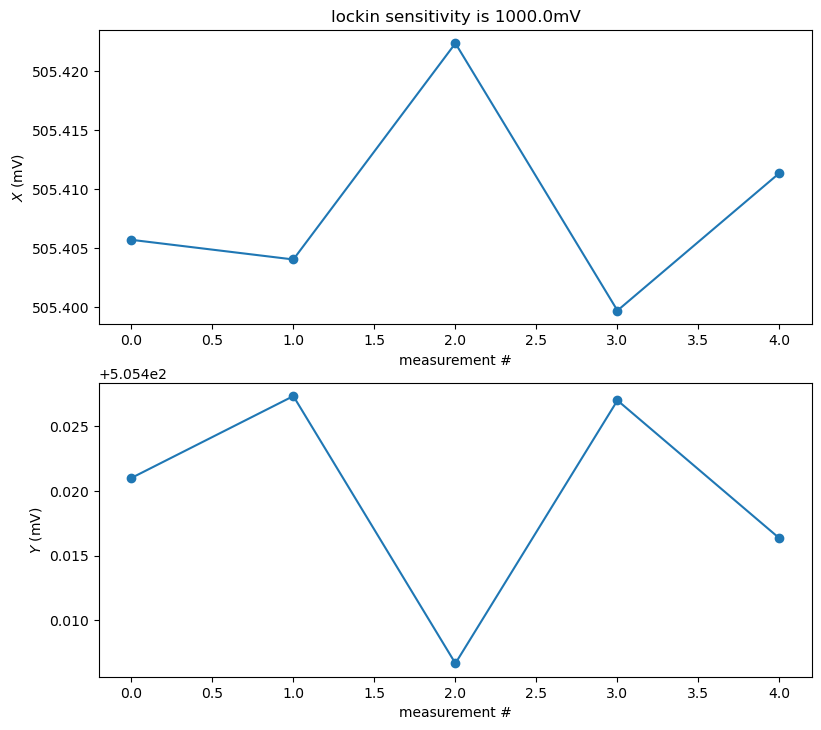

In [4]:
fig, ax = plt.subplots(2,1, figsize = (9.2, 5.6*1.5))
axa, axb = ax

axa.set_title(f'lockin sensitivity is {lockin_gen.sensitivity*1e3}mV')
axa.plot(x_response*1e3, 'o-')
axb.plot(y_response*1e3, 'o-')

axa.set_xlabel('measurement #')
axa.set_ylabel(r'$X$ (mV)')

axb.set_xlabel(axa.get_xlabel())
axb.set_ylabel(r'$Y$ (mV)')
# axa.legend()

Channel X scaling should be off: f(0.0, 1)
Channel Y scaling should be off: f(0.0, 1)


Text(0, 0.5, '$Y$ (mV)')

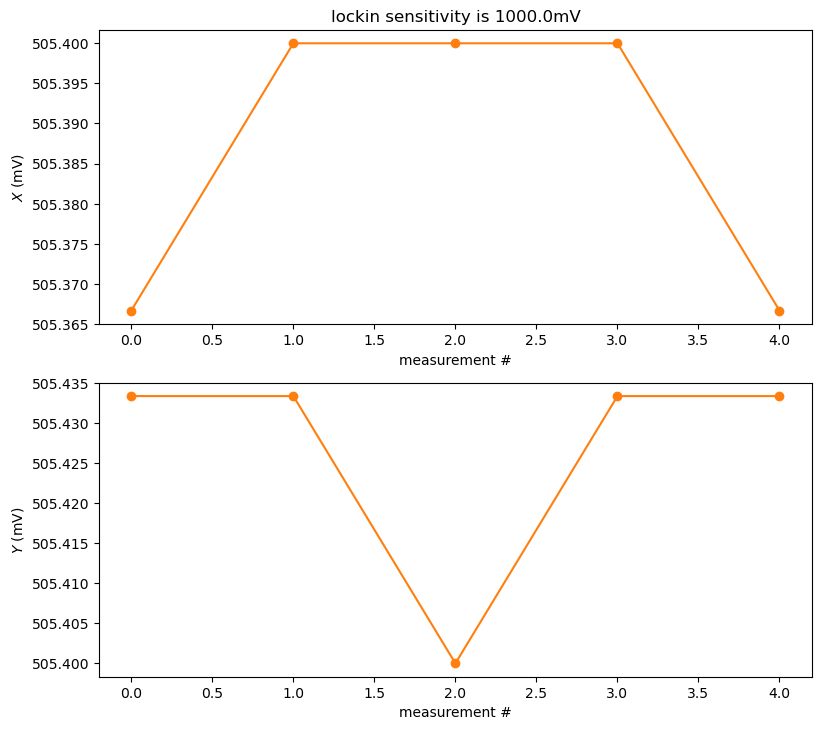

In [5]:
for ch in ['X', 'Y']:
    lockin_gen.set_scaling(ch, 0, 0)
    print(f'Channel {ch} scaling should be off: f{lockin_gen.get_scaling(ch)}')

x_unscale, y_unscale = lockin_gen.buffer_measure_fast(buffer_size, fast=True)

fig, ax = plt.subplots(2,1, figsize = (9.2, 5.6*1.5))
axa, axb = ax

axa.set_title(f'lockin sensitivity is {lockin_gen.sensitivity*1e3}mV')
axa.plot(x_unscale*1e3, 'o-', color = 'tab:orange')
axb.plot(y_unscale*1e3, 'o-', color = 'tab:orange')

axa.set_xlabel('measurement #')
axa.set_ylabel(r'$X$ (mV)')

axb.set_xlabel(axa.get_xlabel())
axb.set_ylabel(r'$Y$ (mV)')
# axa.legend()

Text(0, 0.5, '$Y$ (mV)')

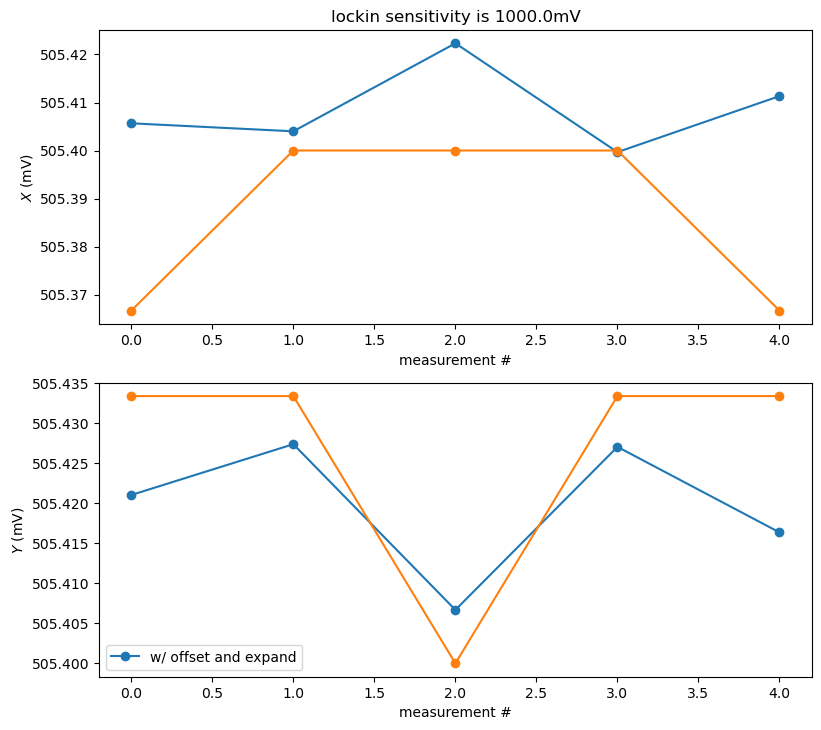

In [6]:
fig, ax = plt.subplots(2,1, figsize = (9.2, 5.6*1.5))
axa, axb = ax

axa.set_title(f'lockin sensitivity is {lockin_gen.sensitivity*1e3}mV')
axa.plot(x_response*1e3, 'o-')
axa.plot(x_unscale*1e3, 'o-')

axb.plot(y_response*1e3, 'o-', label ='w/ offset and expand')
axb.plot(y_unscale*1e3, 'o-')
axb.legend()

axa.set_xlabel('measurement #')
axa.set_ylabel(r'$X$ (mV)')

axb.set_xlabel(axa.get_xlabel())
axb.set_ylabel(r'$Y$ (mV)')

# FAST0 mode test

In [7]:
# from importlib import reload
# reload(srs.SR830)

In [8]:
lockin_gen.buffer_measure_fast(5, fast = False)

(array([0.50537109, 0.50537109, 0.50537109, 0.50537109, 0.50537109]),
 array([0.50537109, 0.50537109, 0.50537109, 0.50537109, 0.50537109]))

# Protocol tests
Per BenediktBurger's suggestion protocol tests might instill confidence in the pull request

In [9]:
from pymeasure.generator import Generator
from pymeasure.instruments import srs

generator = Generator()

# instrument = generator.instantiate(instrument_class=srs.SR830, adapter= lockin_gen.adapter, manufacturer='srs')
# instrument.time_constant = 0.1
# instrument.filter_slope = 24
# instrument.sample_frequency = 1

# # instrument.start_buffer(fast=False)
# # time.sleep(5)
# # instrument.pause_buffer()
# # instrument.get_buffer_bytes()
# instrument.buffer_measure_fast(buffer_size=10, fast=False)
# generator.write_file('auto generated buffer_measure_fast=False.py')
generator = Generator()

instrument = generator.instantiate(instrument_class=srs.SR830, adapter= lockin_gen.adapter, manufacturer='srs')
instrument.time_constant = 0.1
instrument.filter_slope = 24
instrument.sample_frequency = 1

instrument.buffer_measure_fast(buffer_size=10, fast=False)
# instrument.buffer_measure_fast(buffer_size=10, fast = True)
generator.write_file('auto generated buffer_measure_fast.py')

In [10]:
# lockin_gen.start_buffer(fast=False)
# time.sleep(3)
# lockin_gen.pause_buffer()
# lockin_gen.get_buffer_bytes()

lockin_gen.time_constant = 0.1
lockin_gen.filter_slope = 24
lockin_gen.sample_frequency = 1

# instrument.start_buffer(fast=False)
# time.sleep(5)
# instrument.pause_buffer()
# instrument.get_buffer_bytes()
lockin_gen.buffer_measure_fast(buffer_size=10, fast=False)

(array([0.50537109, 0.50537109, 0.50537109, 0.50537109, 0.50537109,
        0.50537109, 0.50537109, 0.50537109, 0.50537109, 0.50537109]),
 array([0.50537109, 0.50537109, 0.50537109, 0.50537109, 0.50537109,
        0.50537109, 0.50537109, 0.50537109, 0.50537109, 0.50537109]))